In [1]:
import re
import json
import emoji
from collections import defaultdict

import torch
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from tqdm import tqdm
from scipy.spatial.distance import cdist

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

from transformers import AutoTokenizer, AutoModelForSequenceClassification


KeyboardInterrupt



# Visualize

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Nhập câu bạn muốn kiểm tra:  I am so sorry for what happened, I feel terrible.


Tổng phương sai được giải thích bởi 2 thành phần chính: 17.59%


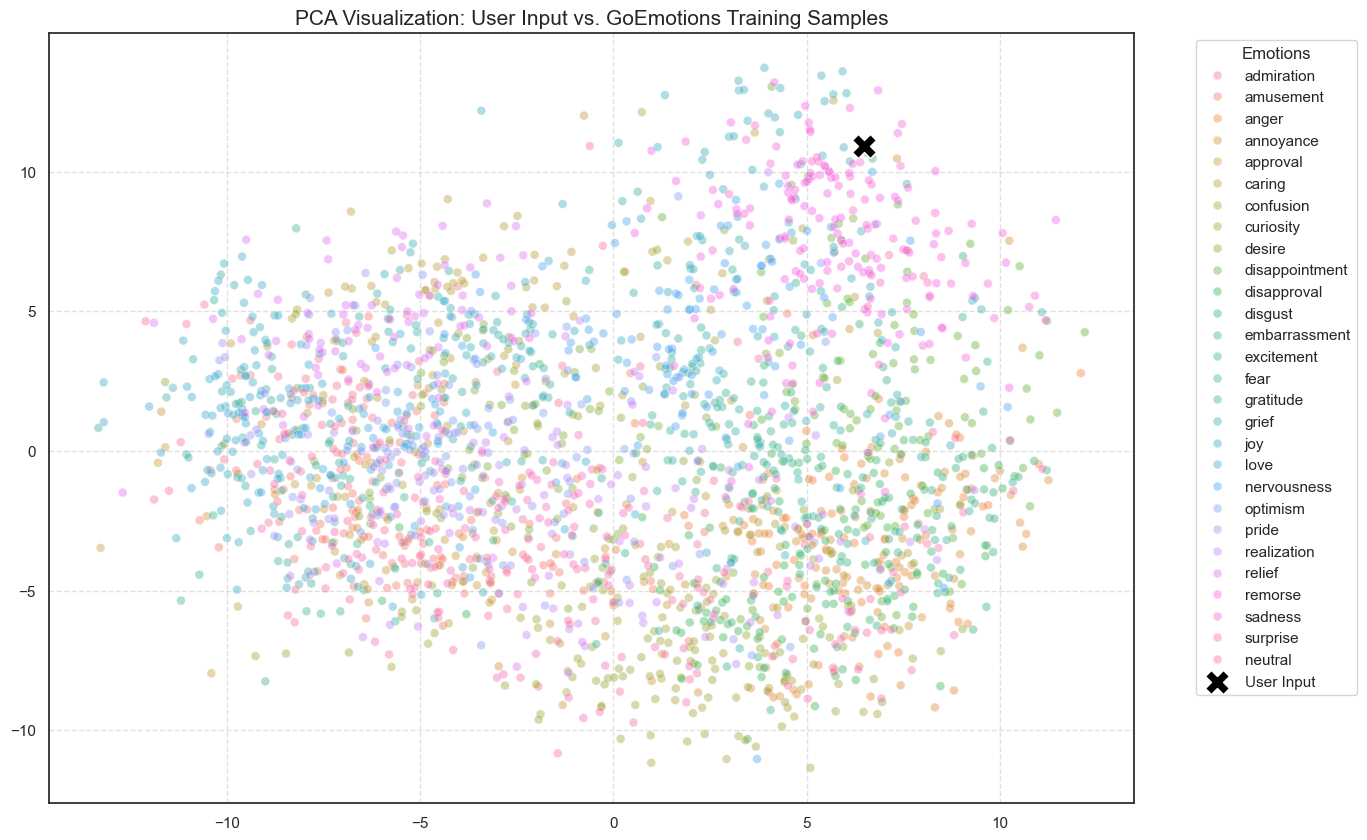

In [9]:
# 1. Cấu hình đường dẫn và Load Model (để trích xuất input người dùng)
model_path = r"./results/checkpoint-10864" # Thay đổi nếu cần
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.to(device)
model.eval()

# 2. Load dữ liệu nền đã lưu trước đó
base_filename = "goemotions_embedded"
bg_embeddings = np.load(f"{base_filename}_embeddings.npy")
bg_metadata = pd.read_csv(f"{base_filename}_metadata.csv")

# 3. Hàm trích xuất embedding cho User Input
def get_user_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding="max_length").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        # Lấy CLS token từ layer cuối
        embedding = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
    return embedding

# --- BẮT ĐẦU XỬ LÝ ---

user_text = input("Nhập câu bạn muốn kiểm tra: ")
user_emb = get_user_embedding(user_text)

# Gộp dữ liệu
all_embeddings = np.vstack([bg_embeddings, user_emb])
all_labels = bg_metadata['label'].tolist() + ['USER_INPUT']

# 4. Thực hiện PCA
# Bạn muốn chọn n_components=2 để vẽ scatter plot 2D chứ?
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(all_embeddings)

# Giải thích toán học: PCA tìm các trục (eigenvectors) mà tại đó dữ liệu biến thiên nhiều nhất
print(f"Tổng phương sai được giải thích bởi 2 thành phần chính: {np.sum(pca.explained_variance_ratio_):.2%}")

# 5. Trực quan hóa
plt.figure(figsize=(14, 10))
sns.set_theme(style="white")

# Vẽ dữ liệu nền (Train samples)
sns.scatterplot(
    x=pca_results[:-1, 0], 
    y=pca_results[:-1, 1],
    hue=bg_metadata['label'],
    palette="husl",
    alpha=0.4,
    s=40,
    legend='full'
)

# Vẽ điểm của User (Nổi bật với màu đen và kích thước lớn)
plt.scatter(
    pca_results[-1, 0], 
    pca_results[-1, 1], 
    c='black', marker='X', s=300, label='User Input', edgecolors='white'
)

plt.title(f"PCA Visualization: User Input vs. GoEmotions Training Samples", fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Emotions")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Nhập câu bạn muốn kiểm tra trên bản đồ t-SNE:  I am so sorry for what happened, I feel terrible.


Đang tính toán t-SNE cho 2501 mẫu... Quá trình này lâu hơn PCA.


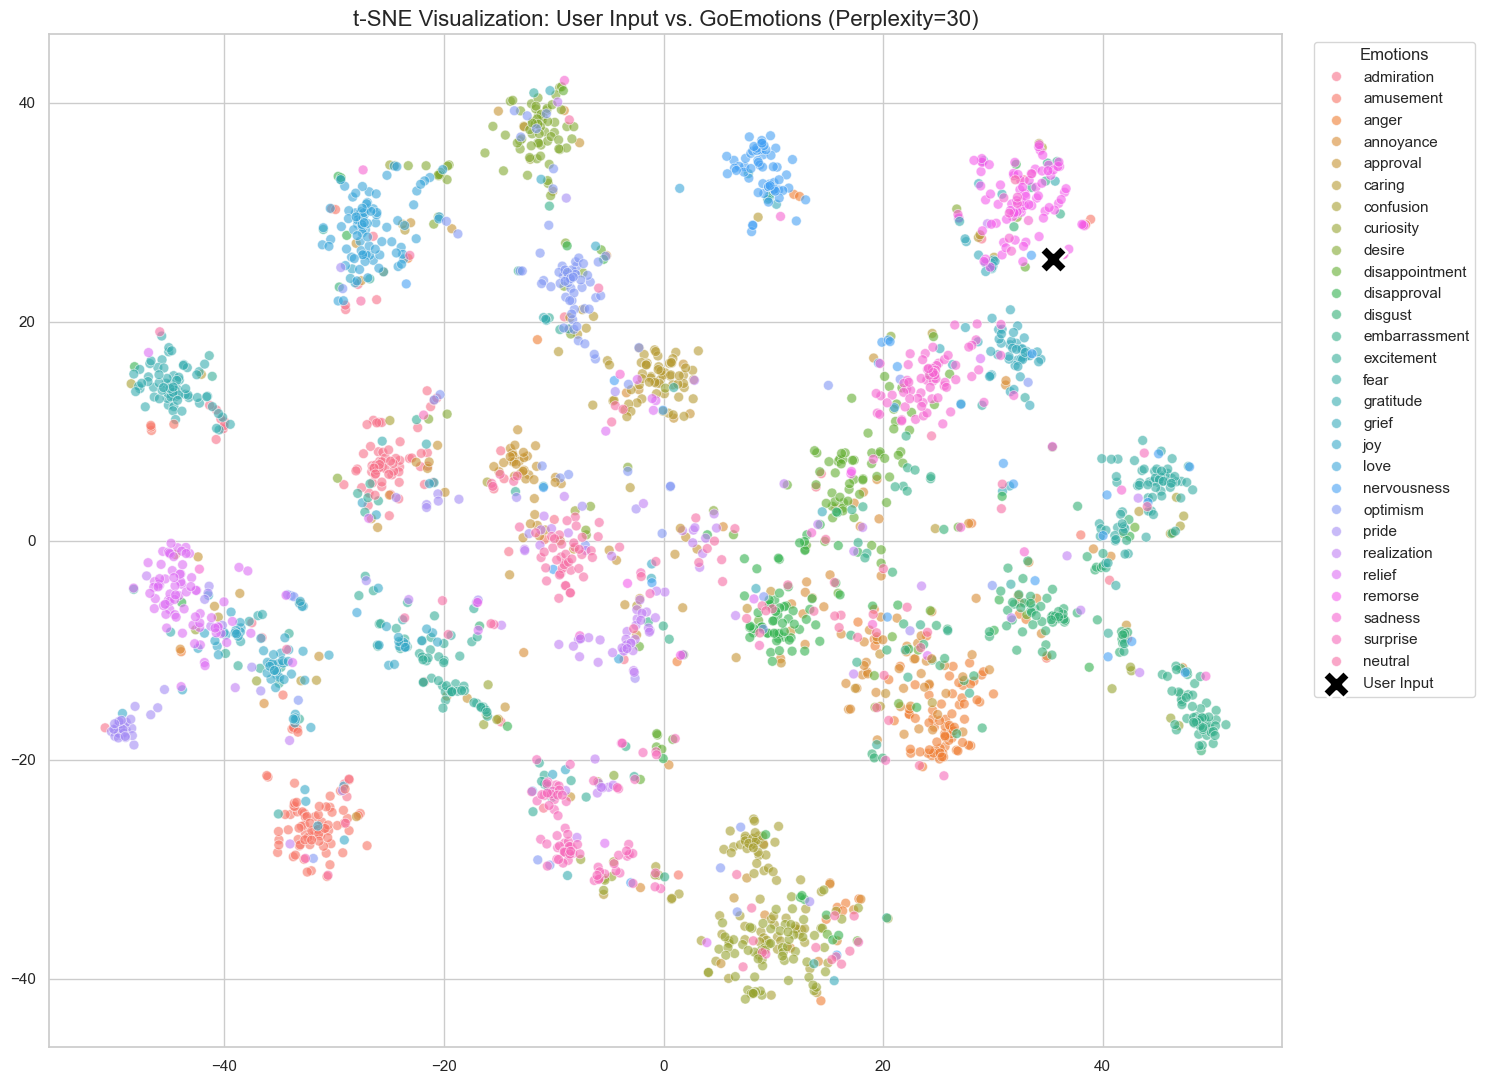

In [11]:
TSNE_PARAMS = {
    "n_components": 2,
    "perplexity": 30,
    "learning_rate": 'auto',
    "metric": 'cosine', 
    "init": 'pca',
    "max_iter": 1000,
    "random_state": 42
}

def get_user_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128, padding="max_length").to(device)
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        # Lấy CLS token từ layer cuối cùng
        embedding = outputs.hidden_states[-1][:, 0, :].cpu().numpy()
    return embedding

# --- 4. Xử lý User Input và Chạy t-SNE ---
user_text = input("Nhập câu bạn muốn kiểm tra trên bản đồ t-SNE: ")
user_emb = get_user_embedding(user_text)

# Gộp dữ liệu: Background + User Input
all_embeddings = np.vstack([bg_embeddings, user_emb])
all_labels = bg_metadata['label'].tolist() + ['USER_INPUT']

print(f"Đang tính toán t-SNE cho {len(all_embeddings)} mẫu... Quá trình này lâu hơn PCA.")
tsne = TSNE(**TSNE_PARAMS)
tsne_results = tsne.fit_transform(all_embeddings)

# --- 5. Trực quan hóa ---
plt.figure(figsize=(15, 11))
sns.set_theme(style="whitegrid")

# Vẽ các điểm nền
sns.scatterplot(
    x=tsne_results[:-1, 0], 
    y=tsne_results[:-1, 1],
    hue=bg_metadata['label'],
    palette="husl",
    alpha=0.6,
    s=50,
    legend='full'
)

# Vẽ điểm User nổi bật
plt.scatter(
    tsne_results[-1, 0], 
    tsne_results[-1, 1], 
    c='black', marker='X', s=400, label='User Input', edgecolors='white', linewidth=2, zorder=10
)

plt.title(f"t-SNE Visualization: User Input vs. GoEmotions (Perplexity={TSNE_PARAMS['perplexity']})", fontsize=16)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Emotions")
plt.tight_layout()
plt.show()

In [16]:
def find_nearest_neighbors(user_point, background_points, metadata, k=3, metric='cosine'):
    distances = cdist(user_point.reshape(1, -1), background_points, metric=metric)[0]
    nearest_indices = np.argsort(distances)[:k]
    
    results = []
    for idx in nearest_indices:
        results.append({
            'text': metadata.iloc[idx]['text'],
            'label': metadata.iloc[idx]['label'],
            'distance': distances[idx]
        })
    return results

user_2d_point = tsne_results[-1]
bg_2d_points = tsne_results[:-1]

neighbors = find_nearest_neighbors(
    user_2d_point, 
    bg_2d_points, 
    bg_metadata, 
    k=3, 
    metric='cosine'
)

print(f"Câu bạn nhập: '{user_text}'\n")
print(f"{'STT':<5} | {'Cảm xúc':<15} | {'Nội dung câu gần nhất'}")
print("-" * 80)
for i, n in enumerate(neighbors, 1):
    print(f"{i:<5} | {n['label']:<15} | {n['text']}")

Câu bạn nhập: 'I am so sorry for what happened, I feel terrible.'

STT   | Cảm xúc         | Nội dung câu gần nhất
--------------------------------------------------------------------------------
1     | fear            | I'm sorry you had a bad experience, that's horrible. But that number saved one of my friends lives. Different for everyone
2     | sadness         | came here to find the person who hasn’t seen this movie so i could feel bad for them
3     | remorse         | Bhahaha! I’m sorry, that sounds awful.


# SVM

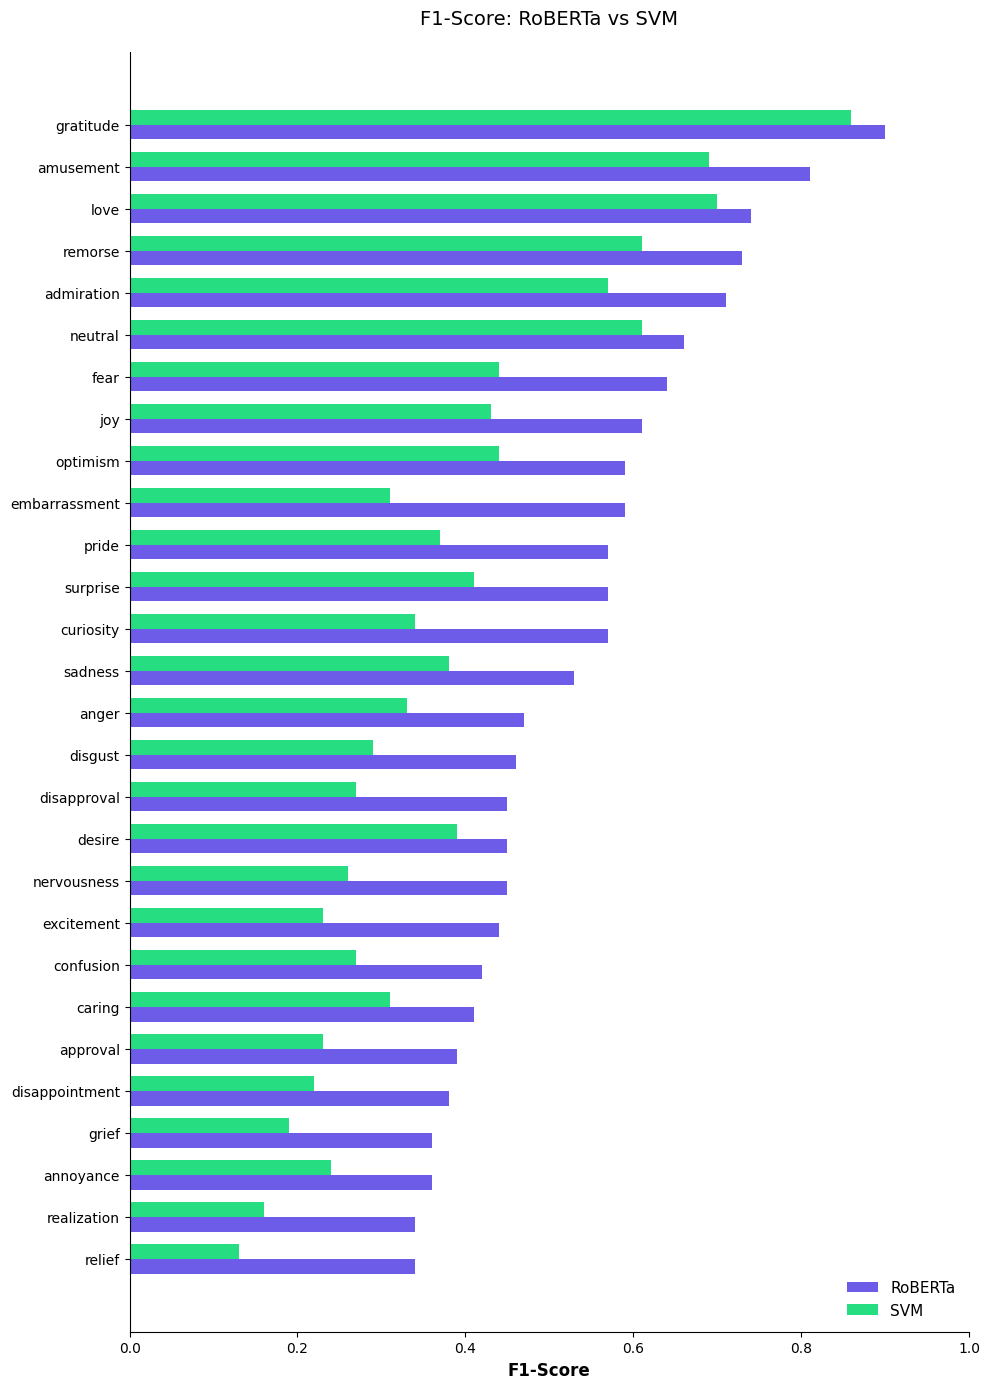

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Chuẩn bị dữ liệu
data = {
    'label': [
        'admiration', 'amusement', 'anger', 'annoyance', 'approval', 'caring', 'confusion', 
        'curiosity', 'desire', 'disappointment', 'disapproval', 'disgust', 'embarrassment', 
        'excitement', 'fear', 'gratitude', 'grief', 'joy', 'love', 'nervousness', 
        'optimism', 'pride', 'realization', 'relief', 'remorse', 'sadness', 'surprise', 'neutral'
    ],
    'RoBERTa_F1': [
        0.71, 0.81, 0.47, 0.36, 0.39, 0.41, 0.42, 0.57, 0.45, 0.38, 0.45, 0.46, 0.59, 
        0.44, 0.64, 0.90, 0.36, 0.61, 0.74, 0.45, 0.59, 0.57, 0.34, 0.34, 0.73, 0.53, 0.57, 0.66
    ],
    'SVM_F1': [
        0.57, 0.69, 0.33, 0.24, 0.23, 0.31, 0.27, 0.34, 0.39, 0.22, 0.27, 0.29, 0.31, 
        0.23, 0.44, 0.86, 0.19, 0.43, 0.70, 0.26, 0.44, 0.37, 0.16, 0.13, 0.61, 0.38, 0.41, 0.61
    ]
}

df = pd.DataFrame(data)

# 2. Sắp xếp giảm dần theo RoBERTa F1 (vẽ từ dưới lên nên dùng ascending=True)
df = df.sort_values(by='RoBERTa_F1', ascending=True)

# 3. Cấu hình màu sắc (Bảng màu Modern Contrast)
color_roberta = '#6C5CE7' # Midnight Blue
color_svm = '#26DE81'     # Carrot Orange

# 4. Vẽ biểu đồ
plt.figure(figsize=(10, 14)) # Nền xám rất nhạt để dịu mắt
ax = plt.subplot(111)

bar_width = 0.35
indices = np.arange(len(df))

# Vẽ cột nhóm đè lên nhau (song song)
ax.barh(indices, df['RoBERTa_F1'], height=bar_width, color=color_roberta, label='RoBERTa')
ax.barh(indices + bar_width, df['SVM_F1'], height=bar_width, color=color_svm, label='SVM')

# 5. Tinh chỉnh hiển thị
plt.xlabel('F1-Score', fontsize=12, fontweight='bold')
plt.title('F1-Score: RoBERTa vs SVM', fontsize=14, pad=20)
plt.yticks(indices + bar_width / 2, df['label'], fontsize=10)
plt.xlim(0, 1.0)
plt.legend(frameon=False, loc='lower right', fontsize=11)

# Thêm lưới dọc mờ để dễ ước lượng giá trị
plt.grid(axis='x', linestyle=':', alpha=0)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()